# Final Generalization (5x5)

This notebook mirrors the `training_pipeline_rollout_debug_5x5` workflow, but it focuses on one method only:

- `sac_her_reward` (`BC + SAC + HER + Reward Shaping`)

The flow is:

1. Train the 5x5 `BC + SAC + HER + Reward Shaping` pipeline once.
2. Build five held-out 5x5 boards using words that do not appear in `training_pipeline_rollout_debug_5x5.ipynb`.
3. Run one full rollout on each held-out board.
4. Show per-board pass / fail, rollout details, and overall performance at the end.

All outputs will be saved to `notebooks/artifacts/final_generalization/`.


In [ ]:
from __future__ import annotations

import random
import re
import sys
from copy import deepcopy
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.env.board import BoardConfig
from src.env.game import CodenamesSpymasterEnv
from src.env.reward import RewardConfig
from src.training import (
    capture_rollout_trace,
    load_config,
    make_pipeline_config,
    run_named_pipeline,
    save_rollout_gif,
)

## Step 1. Load the 5x5 config and set notebook options

By default this notebook keeps the normal 5x5 training config so it is closer to a final run.

If you only want a faster smoke pass first, set `NOTEBOOK_OPTIONS["use_quick_overrides"] = True`.


In [ ]:
BASE_CONFIG = load_config(PROJECT_ROOT / "configs" / "training_pipeline_5x5.yaml")
ARTIFACT_ROOT = PROJECT_ROOT / "notebooks" / "artifacts" / "final_generalization"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

PIPELINE_NAME = "sac_her_reward"
PIPELINE_LABEL = "BC + SAC + HER + Reward Shaping"

NOTEBOOK_OPTIONS = {
    "refresh_hints": False,
    "use_quick_overrides": False,
    "num_holdout_boards": 5,
    "holdout_seed": 2026,
}


def prepare_hint_file(base_config: dict, *, refresh_hints: bool) -> Path:
    hint_path = PROJECT_ROOT / base_config["data"]["clue_words_path"]
    hint_path.parent.mkdir(parents=True, exist_ok=True)

    if refresh_hints and hint_path.exists():
        hint_path.unlink()
        print(f"Removed existing hint file: {hint_path.relative_to(PROJECT_ROOT)}")
    elif refresh_hints:
        print(f"Hint file will be regenerated: {hint_path.relative_to(PROJECT_ROOT)}")
    elif hint_path.exists():
        print(f"Reusing existing hint file: {hint_path.relative_to(PROJECT_ROOT)}")
    else:
        print(
            f"Hint file is missing and will be generated: {hint_path.relative_to(PROJECT_ROOT)}"
        )

    return hint_path


HINTS_PATH = prepare_hint_file(
    BASE_CONFIG,
    refresh_hints=NOTEBOOK_OPTIONS["refresh_hints"],
)

COMMON_OVERRIDES = {
    "name": "final_generalization",
    "embedding": {"max_clues": 1200},
}

if NOTEBOOK_OPTIONS["use_quick_overrides"]:
    COMMON_OVERRIDES["bc"] = {
        "demo_episodes": 6,
        "pretrain_epochs": 2,
        "batch_size": 32,
    }
    COMMON_OVERRIDES["training"] = {
        "total_timesteps": 120,
        "learning_starts": 20,
        "batch_size": 32,
        "net_arch": [128, 128],
    }
    COMMON_OVERRIDES["evaluation"] = {
        "episodes": 2,
        "deterministic": True,
    }

TRAINING_OUTPUT_DIR = (
    Path("notebooks") / "artifacts" / "final_generalization" / "trained_agent"
)
TRAINING_CONFIG = make_pipeline_config(
    deepcopy(BASE_CONFIG),
    PIPELINE_NAME,
    output_dir=str(TRAINING_OUTPUT_DIR),
    extra_overrides=deepcopy(COMMON_OVERRIDES),
)

pd.DataFrame(
    [
        {
            "pipeline": PIPELINE_NAME,
            "agent": PIPELINE_LABEL,
            "rows": TRAINING_CONFIG["env"]["rows"],
            "cols": TRAINING_CONFIG["env"]["cols"],
            "total_timesteps": TRAINING_CONFIG["training"]["total_timesteps"],
            "demo_episodes": TRAINING_CONFIG["bc"]["demo_episodes"],
            "pretrain_epochs": TRAINING_CONFIG["bc"]["pretrain_epochs"],
            "holdout_boards": NOTEBOOK_OPTIONS["num_holdout_boards"],
            "quick_mode": NOTEBOOK_OPTIONS["use_quick_overrides"],
        }
    ]
)

Reusing existing hint file: data/raw/common_words.txt


,pipeline,agent,rows,cols,total_timesteps,demo_episodes,pretrain_epochs,holdout_boards,quick_mode
0,sac_her_reward,BC + SAC + HER + Reward Shaping,5,5,8000,500,30,5,False


## Step 2. Build five held-out 5x5 boards

To honor the generalization requirement, this notebook excludes any Codenames board word that appears in `training_pipeline_rollout_debug_5x5.ipynb`, then samples five new 25-word boards from the remaining pool.


In [ ]:
DEBUG_NOTEBOOK_PATH = (
    PROJECT_ROOT / "notebooks" / "training_pipeline_rollout_debug_5x5.ipynb"
)
BOARD_WORDS_PATH = PROJECT_ROOT / TRAINING_CONFIG["data"]["board_words_path"]


def load_board_words(board_words_path: Path) -> list[str]:
    return [
        line.strip().upper()
        for line in board_words_path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]


def extract_debug_notebook_words(
    debug_notebook_path: Path,
    board_words_path: Path,
) -> set[str]:
    notebook_text = debug_notebook_path.read_text(encoding="utf-8").upper()
    notebook_tokens = set(re.findall(r"[A-Z][A-Z]+", notebook_text))
    board_words = load_board_words(board_words_path)
    return {word for word in board_words if word in notebook_tokens}


def build_holdout_boards(
    board_words: list[str],
    excluded_words: set[str],
    *,
    num_boards: int,
    board_size: int,
    seed: int,
) -> list[dict[str, object]]:
    remaining_words = [word for word in board_words if word not in excluded_words]
    required_words = num_boards * board_size
    if len(remaining_words) < required_words:
        raise ValueError(
            f"Need {required_words} held-out words, but only found {len(remaining_words)}."
        )

    rng = random.Random(seed)
    shuffled = remaining_words.copy()
    rng.shuffle(shuffled)

    boards: list[dict[str, object]] = []
    for index in range(num_boards):
        start = index * board_size
        stop = start + board_size
        board_words_slice = shuffled[start:stop]
        boards.append(
            {
                "board_id": f"board_{index + 1}",
                "display_name": f"Board {index + 1}",
                "words": board_words_slice,
            }
        )
    return boards


ALL_BOARD_WORDS = load_board_words(BOARD_WORDS_PATH)
EXCLUDED_WORDS = extract_debug_notebook_words(DEBUG_NOTEBOOK_PATH, BOARD_WORDS_PATH)
HOLDOUT_BOARDS = build_holdout_boards(
    ALL_BOARD_WORDS,
    EXCLUDED_WORDS,
    num_boards=NOTEBOOK_OPTIONS["num_holdout_boards"],
    board_size=TRAINING_CONFIG["env"]["rows"] * TRAINING_CONFIG["env"]["cols"],
    seed=NOTEBOOK_OPTIONS["holdout_seed"],
)

for board in HOLDOUT_BOARDS:
    overlap = set(board["words"]) & EXCLUDED_WORDS
    if overlap:
        raise AssertionError(
            f"Held-out board still contains excluded words: {sorted(overlap)}"
        )

holdout_board_overview_df = pd.DataFrame(
    [
        {
            "board_id": board["board_id"],
            "display_name": board["display_name"],
            "num_words": len(board["words"]),
            "words": ", ".join(board["words"]),
        }
        for board in HOLDOUT_BOARDS
    ]
)

display(
    pd.DataFrame(
        [
            {
                "excluded_words_found_in_debug_notebook": len(EXCLUDED_WORDS),
                "remaining_word_pool": len(ALL_BOARD_WORDS) - len(EXCLUDED_WORDS),
                "holdout_seed": NOTEBOOK_OPTIONS["holdout_seed"],
                "holdout_boards": len(HOLDOUT_BOARDS),
            }
        ]
    )
)
holdout_board_overview_df

,excluded_words_found_in_debug_notebook,remaining_word_pool,holdout_seed,holdout_boards
0,79,321,2026,5


,board_id,display_name,num_words,words
0,board_1,Board 1,25,"FENCE, KANGAROO, PIPE, CONCERT, JUPITER, BOOM,..."
1,board_2,Board 2,25,"ORGAN, DRAGON, CHAIR, FAIR, DRAFT, PUPIL, HORS..."
2,board_3,Board 3,25,"SOCK, APPLE, BOARD, REVOLUTION, SLIP, DECK, WO..."
3,board_4,Board 4,25,"SERVER, TELESCOPE, BEIJING, BEACH, STOCK, HOSP..."
4,board_5,Board 5,25,"DRESS, BOLT, DEATH, SHOP, CARROT, GERMANY, CHU..."


## Step 3. Define shared helpers for one training run plus five held-out evaluations

The trained `sac_her_reward` agent is reused across all five held-out boards. Each board gets its own fixed 5x5 word list and its own rollout GIF / step table.


In [ ]:
def board_words_grid_df(words: list[str], cols: int) -> pd.DataFrame:
    rows = [words[i : i + cols] for i in range(0, len(words), cols)]
    return pd.DataFrame(
        rows,
        index=[f"row_{idx + 1}" for idx in range(len(rows))],
        columns=[f"col_{idx + 1}" for idx in range(cols)],
    )


def make_holdout_env_factory(
    config: dict,
    embedding_store,
    board_words: list[str],
    *,
    seed_offset: int,
):
    data_cfg = config["data"]
    env_cfg = config["env"]
    reward_cfg = config["reward"]
    base_seed = config.get("seed", 0) + seed_offset
    call_state = {"count": 0}

    def factory():
        env_seed = base_seed + call_state["count"]
        call_state["count"] += 1
        board_config = BoardConfig(
            rows=env_cfg["rows"],
            cols=env_cfg["cols"],
            num_friendly=env_cfg["num_friendly"],
            num_opponent=env_cfg["num_opponent"],
            num_neutral=env_cfg["num_neutral"],
            num_assassin=env_cfg["num_assassin"],
            seed=env_seed,
        )
        return CodenamesSpymasterEnv(
            board_words_path=str(PROJECT_ROOT / data_cfg["board_words_path"]),
            clue_words_path=str(PROJECT_ROOT / data_cfg["clue_words_path"]),
            embedding_store=embedding_store,
            board_config=board_config,
            reward_config=RewardConfig(
                turn_penalty=reward_cfg["turn_penalty"],
                opponent_penalty=reward_cfg.get("opponent_penalty", -3.0),
                neutral_penalty=reward_cfg.get("neutral_penalty", -1.5),
                assassin_penalty=reward_cfg["assassin_penalty"],
                shaped_weight=reward_cfg["shaped_weight"],
            ),
            embedding_dim=embedding_store.dimension,
            max_turns=env_cfg["max_turns"],
            max_clue_count=env_cfg["max_clue_count"],
            goal_size=env_cfg["goal_size"],
            seed=env_seed,
            fixed_board_words=board_words,
            shuffle_fixed_board_words=False,
        )

    return factory


def build_generalization_summary_row(
    board: dict[str, object], trace, gif_path: Path
) -> dict[str, object]:
    trace_summary = trace.summary()
    friendly_total = TRAINING_CONFIG["env"]["num_friendly"]
    friendly_remaining = int(trace_summary["friendly_remaining"])
    return {
        "board_id": board["board_id"],
        "board": board["display_name"],
        "status": "pass" if trace_summary["won"] else "fail",
        "won": bool(trace_summary["won"]),
        "assassin_hit": bool(trace_summary["assassin_hit"]),
        "turns": int(trace.final_frame.turn_index),
        "steps": int(trace_summary["steps"]),
        "total_reward": round(float(trace_summary["total_reward"]), 3),
        "friendly_revealed": friendly_total - friendly_remaining,
        "friendly_remaining": friendly_remaining,
        "gif": str(gif_path.relative_to(PROJECT_ROOT)),
        "words": ", ".join(board["words"]),
    }


def run_holdout_board(board: dict[str, object], training_result):
    board_index = int(str(board["board_id"]).split("_")[-1])
    env_factory = make_holdout_env_factory(
        training_result.config,
        training_result.runtime.embedding_store,
        list(board["words"]),
        seed_offset=5000 + board_index * 100,
    )
    trace = capture_rollout_trace(
        training_result.agent,
        env_factory,
        pipeline_name=training_result.pipeline_name,
        agent_label=training_result.agent_label,
        deterministic=training_result.config["evaluation"]["deterministic"],
    )
    gif_path = save_rollout_gif(
        trace,
        ARTIFACT_ROOT / str(board["board_id"]) / f"{board['board_id']}_rollout.gif",
        duration_ms=1200,
    )
    summary_df = pd.DataFrame(
        [build_generalization_summary_row(board, trace, gif_path)]
    )
    steps_df = pd.DataFrame(trace.to_rows())

    display(Markdown(f"## {board['display_name']}"))
    display(Markdown(f"Held-out words for `{board['board_id']}`"))
    display(board_words_grid_df(list(board["words"]), TRAINING_CONFIG["env"]["cols"]))
    display(Markdown(f"Artifacts saved to `{gif_path.relative_to(PROJECT_ROOT)}`"))
    display(Image(filename=str(gif_path)))
    display(summary_df)
    display(steps_df)

    return {
        "board": board,
        "trace": trace,
        "gif_path": gif_path,
        "summary_df": summary_df,
        "steps_df": steps_df,
    }

## Step 4. Train the `BC + SAC + HER + Reward Shaping` 5x5 pipeline once

This is the only training run. Everything after this point is held-out generalization testing on new boards.


In [ ]:
training_result = run_named_pipeline(TRAINING_CONFIG, pipeline_name=PIPELINE_NAME)

training_reference_df = pd.DataFrame(
    [
        {
            "pipeline": training_result.pipeline_name,
            "agent": training_result.agent_label,
            "train_eval_win_rate": round(training_result.agent_metrics["win_rate"], 3),
            "train_eval_assassin_rate": round(
                training_result.agent_metrics["assassin_rate"], 3
            ),
            "train_eval_mean_return": round(
                training_result.agent_metrics["mean_return"], 3
            ),
            "train_eval_mean_turns": round(
                training_result.agent_metrics["mean_turns"], 3
            ),
            "train_eval_friendly_reveal_rate": round(
                training_result.agent_metrics["friendly_reveal_rate"], 3
            ),
            "demo_transitions": training_result.demo_transitions,
            "model_path": training_result.model_path,
            "metrics_path": training_result.metrics_path,
        }
    ]
)

display(Markdown(f"## {PIPELINE_LABEL}"))
training_reference_df

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Users/sungtsewu/miniforge3/envs/rl-310/lib/python3.10/site-packages/stable_baselines3/common/buffers.py:607: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 1.70GB > 0.92GB
  warnings.warn(


## BC + SAC + HER + Reward Shaping

,pipeline,agent,train_eval_win_rate,train_eval_assassin_rate,train_eval_mean_return,train_eval_mean_turns,train_eval_friendly_reveal_rate,demo_transitions,model_path,metrics_path
0,sac_her_reward,BC + SAC + HER + Reward Shaping,0.0,1.0,-68.682,11.667,0.407,4891,/Users/sungtsewu/Desktop/temp_github/Codenames...,/Users/sungtsewu/Desktop/temp_github/Codenames...


## Step 5. Run five held-out generalization rollouts

Each held-out board is evaluated once with a full rollout trace, GIF, and step-by-step table.


## Board 1

Held-out words for `board_1`

,col_1,col_2,col_3,col_4,col_5
row_1,FENCE,KANGAROO,PIPE,CONCERT,JUPITER
row_2,BOOM,PANTS,SOUL,FIRE,ROBOT
row_3,KNIGHT,TEACHER,DOCTOR,SQUARE,BUCK
row_4,CROWN,HEART,ENGLAND,LINE,PIN
row_5,CAPITAL,AUSTRALIA,MOSCOW,CENTER,PAPER


Artifacts saved to `notebooks/artifacts/final_generalization/board_1/board_1_rollout.gif`

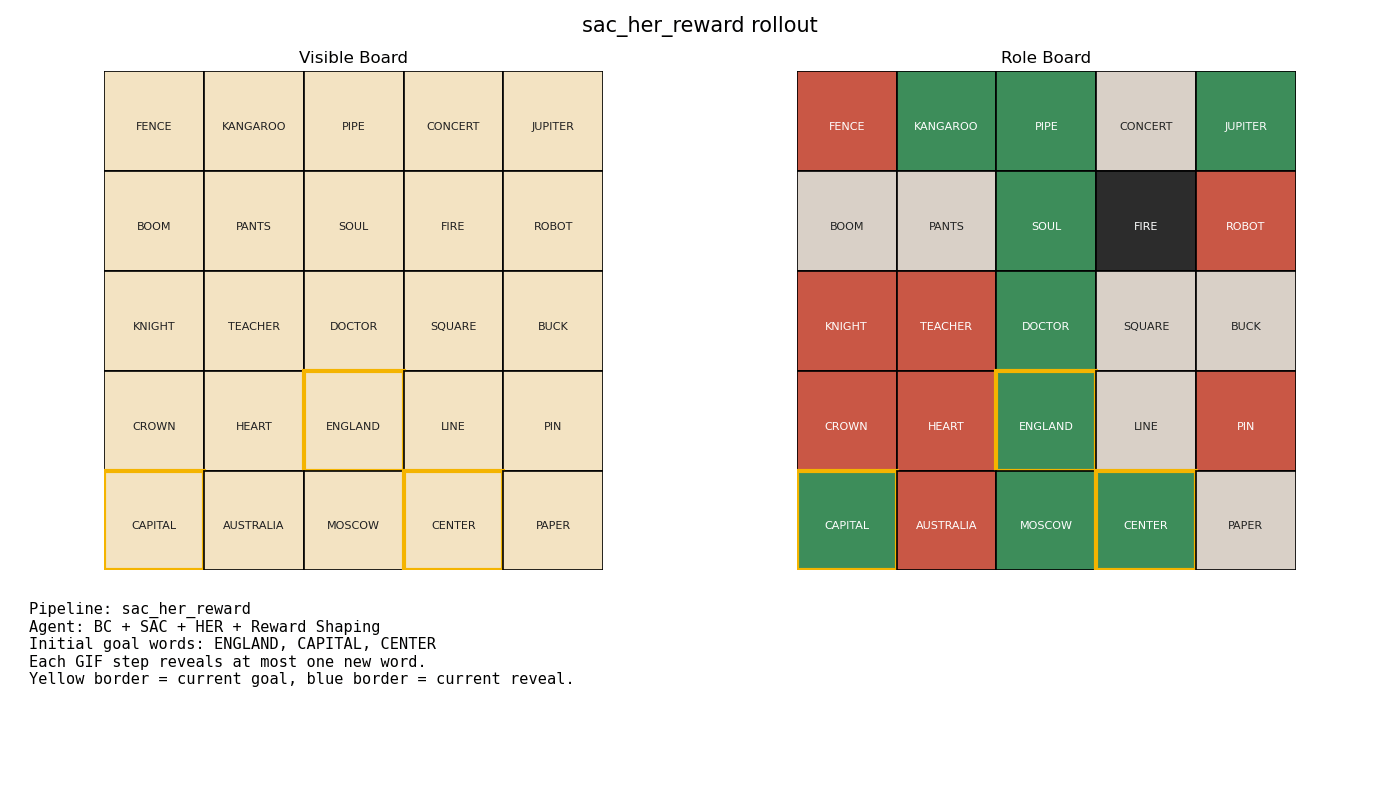

,board_id,board,status,won,assassin_hit,turns,steps,total_reward,friendly_revealed,friendly_remaining,gif,words
0,board_1,Board 1,fail,False,True,5,5,-54.499,0,9,notebooks/artifacts/final_generalization/board...,"FENCE, KANGAROO, PIPE, CONCERT, JUPITER, BOOM,..."


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,proper,1,"ENGLAND, CAPITAL, CENTER",BOOM,neutral,-2.605911,-2.605911,9,False,False
1,2,2,1,natural,1,"ENGLAND, CAPITAL, CENTER",CROWN,opponent,-4.097119,-6.703030,9,False,False
2,3,3,1,great,1,"ENGLAND, CAPITAL, CENTER",LINE,neutral,-2.588049,-9.291080,9,False,False
3,4,4,1,should,1,"ENGLAND, CAPITAL, CENTER",TEACHER,opponent,-4.102158,-13.393238,9,False,False
4,5,5,1,blanket,1,"ENGLAND, CAPITAL, CENTER",FIRE,assassin,-41.105978,-54.499216,9,False,True


## Board 2

Held-out words for `board_2`

,col_1,col_2,col_3,col_4,col_5
row_1,ORGAN,DRAGON,CHAIR,FAIR,DRAFT
row_2,PUPIL,HORSE,NOVEL,BRIDGE,FACE
row_3,LEPRECHAUN,LUCK,TURKEY,LIFE,GOLD
row_4,SPIKE,PILOT,NINJA,SHADOW,MEXICO
row_5,BARK,PYRAMID,IRON,PASS,HORSESHOE


Artifacts saved to `notebooks/artifacts/final_generalization/board_2/board_2_rollout.gif`

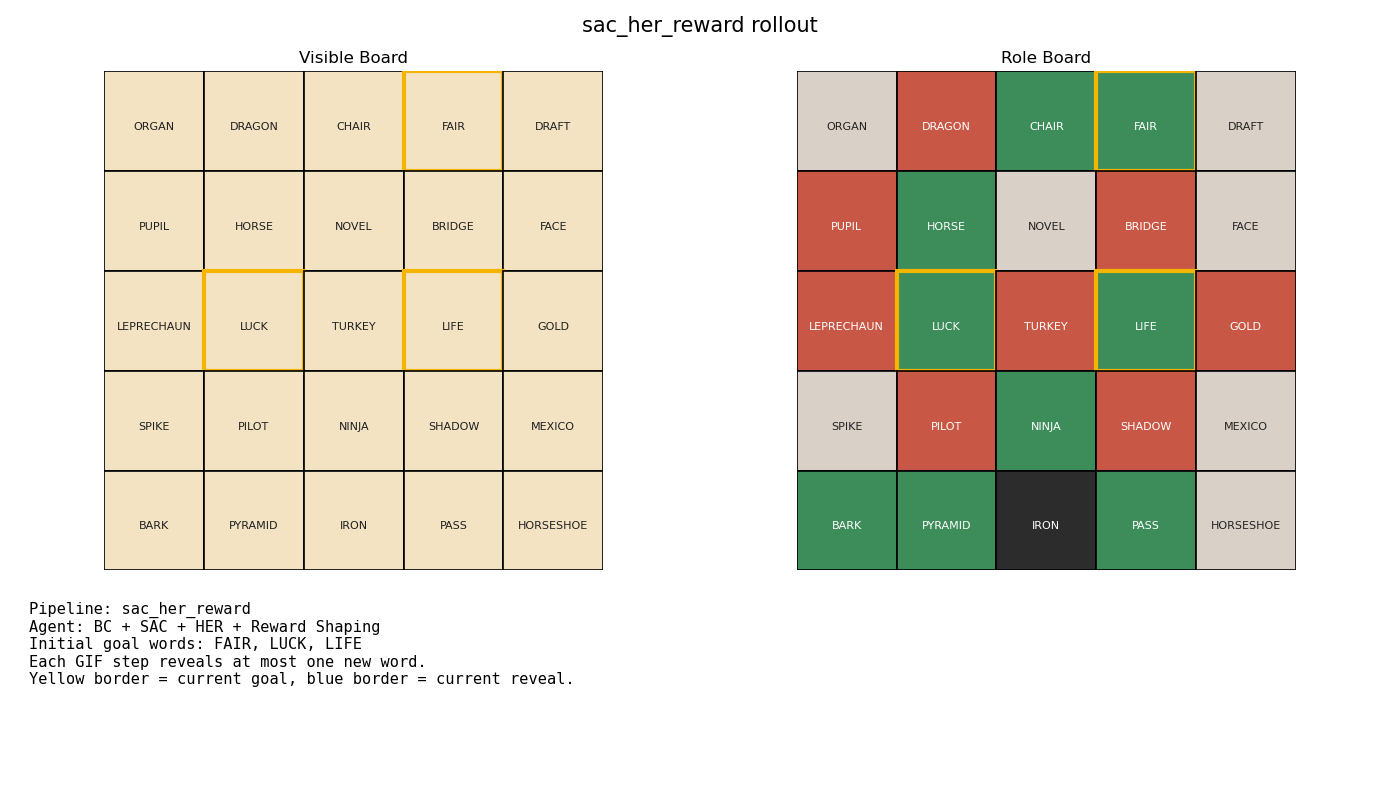

,board_id,board,status,won,assassin_hit,turns,steps,total_reward,friendly_revealed,friendly_remaining,gif,words
0,board_2,Board 2,fail,False,True,5,5,-49.788,2,7,notebooks/artifacts/final_generalization/board...,"ORGAN, DRAGON, CHAIR, FAIR, DRAFT, PUPIL, HORS..."


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,proper,1,"FAIR, LUCK, LIFE",FAIR,friendly,-1.022010,-1.022010,8,False,False
1,2,2,1,natural,1,"LUCK, LIFE, PASS",FACE,neutral,-2.575306,-3.597316,8,False,False
2,3,3,1,great,1,"LUCK, LIFE, PASS",GOLD,opponent,-4.111551,-7.708867,8,False,False
3,4,4,1,should,1,"LUCK, LIFE, PASS",PASS,friendly,-0.964793,-8.673659,7,False,False
4,5,5,1,blanket,1,"HORSE, LUCK, LIFE",IRON,assassin,-41.114155,-49.787814,7,False,True


## Board 3

Held-out words for `board_3`

,col_1,col_2,col_3,col_4,col_5
row_1,SOCK,APPLE,BOARD,REVOLUTION,SLIP
row_2,DECK,WORM,FIELD,THUMB,TOWER
row_3,SMUGGLER,DUCK,SHARK,SPACE,MARBLE
row_4,POST,CASINO,PUMPKIN,LION,FOREST
row_5,AZTEC,CHINA,LOCH NESS,CHOCOLATE,RULER


Artifacts saved to `notebooks/artifacts/final_generalization/board_3/board_3_rollout.gif`

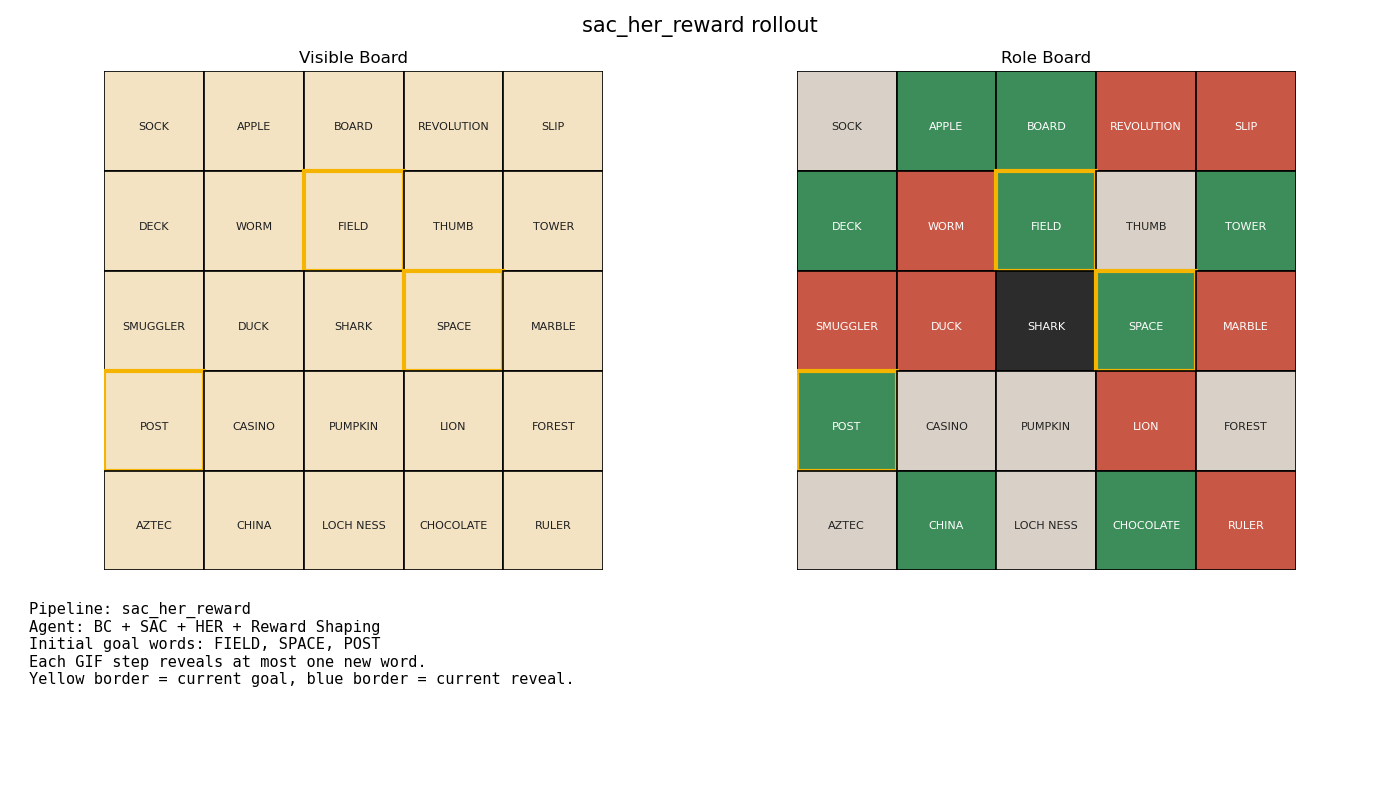

,board_id,board,status,won,assassin_hit,turns,steps,total_reward,friendly_revealed,friendly_remaining,gif,words
0,board_3,Board 3,fail,False,True,8,8,-58.95,3,6,notebooks/artifacts/final_generalization/board...,"SOCK, APPLE, BOARD, REVOLUTION, SLIP, DECK, WO..."


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,proper,1,"FIELD, SPACE, POST",SPACE,friendly,-0.999260,-0.999260,8,False,False
1,2,2,1,natural,1,"BOARD, DECK, TOWER",FIELD,friendly,-1.048516,-2.047776,7,False,False
2,3,3,1,great,1,"BOARD, DECK, TOWER",REVOLUTION,opponent,-4.050699,-6.098475,7,False,False
3,4,4,1,should,1,"BOARD, DECK, TOWER",POST,friendly,-1.042473,-7.140948,6,False,False
4,5,5,1,blanket,1,"BOARD, DECK, TOWER",SLIP,opponent,-4.101339,-11.242288,6,False,False
5,6,6,1,ideal,1,"BOARD, DECK, TOWER",CASINO,neutral,-2.572775,-13.815063,6,False,False
6,7,7,1,correct,1,"BOARD, DECK, TOWER",LION,opponent,-4.060746,-17.875809,6,False,False
7,8,8,1,really,1,"BOARD, DECK, TOWER",SHARK,assassin,-41.073808,-58.949616,6,False,True


## Board 4

Held-out words for `board_4`

,col_1,col_2,col_3,col_4,col_5
row_1,SERVER,TELESCOPE,BEIJING,BEACH,STOCK
row_2,HOSPITAL,CRANE,NEEDLE,POOL,COMPOUND
row_3,MOON,SPIDER,SCORPION,SCHOOL,CRICKET
row_4,EMBASSY,TRIANGLE,BELT,DISEASE,SPELL
row_5,AMERICA,PISTOL,CROSS,PARK,RACKET


Artifacts saved to `notebooks/artifacts/final_generalization/board_4/board_4_rollout.gif`

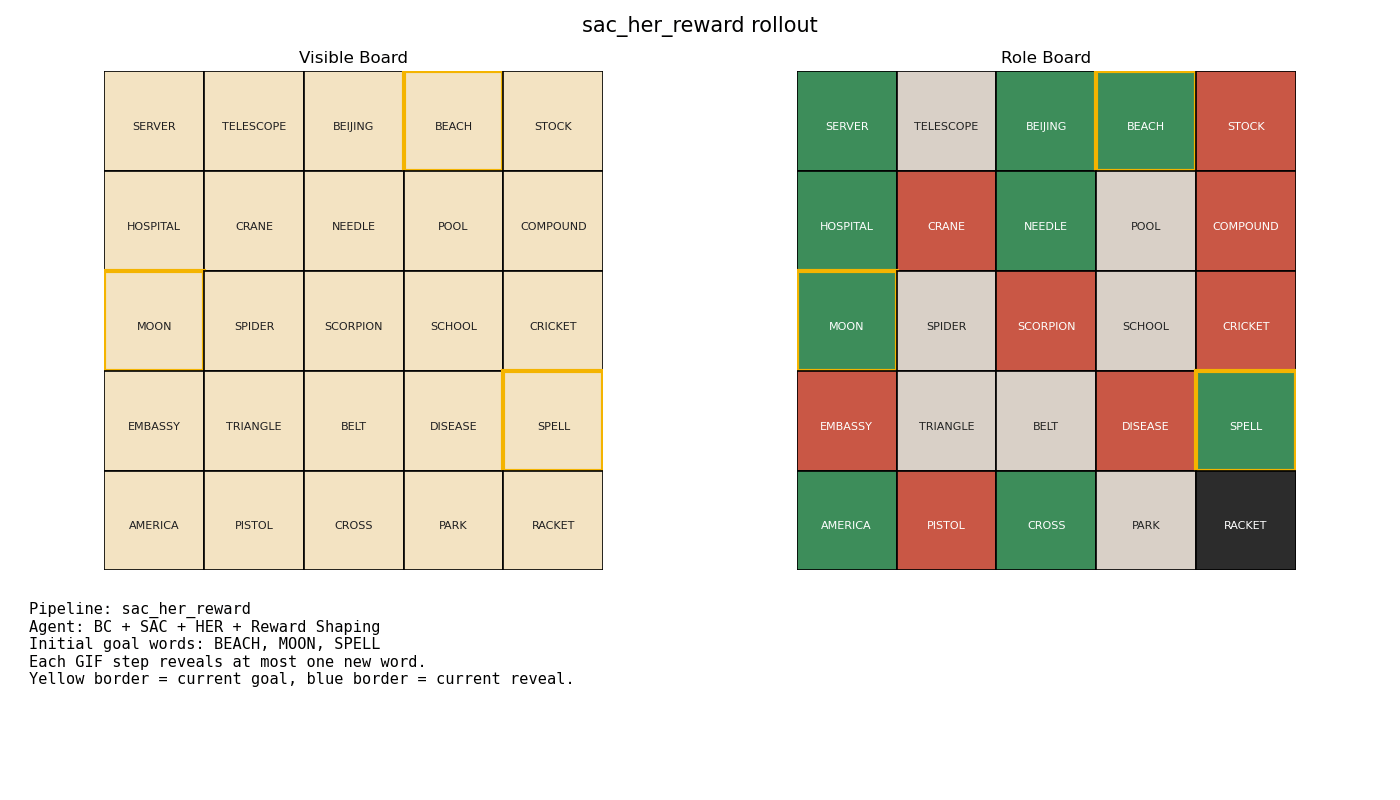

,board_id,board,status,won,assassin_hit,turns,steps,total_reward,friendly_revealed,friendly_remaining,gif,words
0,board_4,Board 4,fail,False,False,20,20,-50.004,8,1,notebooks/artifacts/final_generalization/board...,"SERVER, TELESCOPE, BEIJING, BEACH, STOCK, HOSP..."


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,proper,1,"BEACH, MOON, SPELL",SPELL,friendly,-1.061381,-1.061381,8,False,False
1,2,2,1,natural,1,"SERVER, BEACH, MOON",COMPOUND,opponent,-4.123379,-5.184760,8,False,False
2,3,3,1,great,1,"SERVER, BEACH, MOON",SCHOOL,neutral,-2.550729,-7.735490,8,False,False
3,4,4,1,should,1,"SERVER, BEACH, MOON",CROSS,friendly,-1.028071,-8.763561,7,False,False
4,5,5,1,blanket,1,"SERVER, BEACH, MOON",NEEDLE,friendly,-1.083571,-9.847132,6,False,False
5,6,6,1,ideal,1,"SERVER, BEACH, MOON",AMERICA,friendly,-1.044838,-10.891970,5,False,False
6,7,7,1,correct,1,"SERVER, BEACH, MOON",MOON,friendly,-1.043650,-11.935620,4,False,False
7,8,8,1,really,1,"SERVER, BEACH, HOSPITAL",TRIANGLE,neutral,-2.526548,-14.462168,4,False,False
8,9,9,1,concept,1,"SERVER, BEACH, HOSPITAL",SPIDER,neutral,-2.556974,-17.019142,4,False,False
9,10,10,1,meaning,1,"SERVER, BEACH, HOSPITAL",SERVER,friendly,-1.039388,-18.058530,3,False,False


## Board 5

Held-out words for `board_5`

,col_1,col_2,col_3,col_4,col_5
row_1,DRESS,BOLT,DEATH,SHOP,CARROT
row_2,GERMANY,CHURCH,BILL,OLIVE,POUND
row_3,BEAT,KETCHUP,FIGURE,DIAMOND,CZECH
row_4,SPY,NAIL,BAT,SCUBA DIVER,SINK
row_5,LASER,HOTEL,DRILL,UNDERTAKER,YARD


Artifacts saved to `notebooks/artifacts/final_generalization/board_5/board_5_rollout.gif`

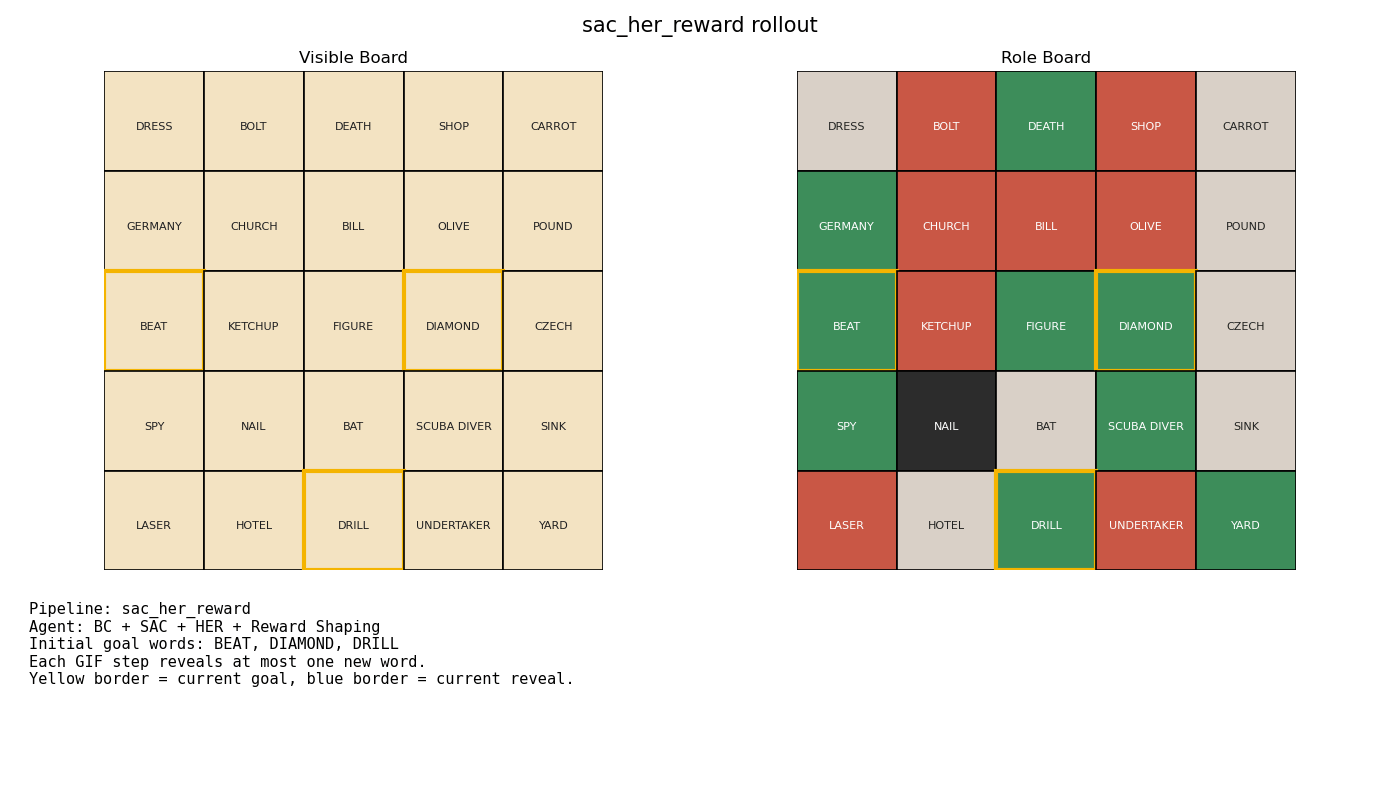

,board_id,board,status,won,assassin_hit,turns,steps,total_reward,friendly_revealed,friendly_remaining,gif,words
0,board_5,Board 5,fail,False,True,5,5,-49.755,2,7,notebooks/artifacts/final_generalization/board...,"DRESS, BOLT, DEATH, SHOP, CARROT, GERMANY, CHU..."


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,proper,1,"BEAT, DIAMOND, DRILL",BILL,opponent,-4.071162,-4.071162,9,False,False
1,2,2,1,natural,1,"BEAT, DIAMOND, DRILL",DIAMOND,friendly,-1.014035,-5.085197,8,False,False
2,3,3,1,great,1,"DEATH, BEAT, DRILL",DRILL,friendly,-1.036612,-6.121809,7,False,False
3,4,4,1,should,1,"DEATH, BEAT, SPY",DRESS,neutral,-2.556438,-8.678247,7,False,False
4,5,5,1,blanket,1,"DEATH, BEAT, SPY",NAIL,assassin,-41.076969,-49.755215,7,False,True


In [ ]:
holdout_runs = [run_holdout_board(board, training_result) for board in HOLDOUT_BOARDS]

## Step 6. Final board-by-board result and overall performance

The table below gives the simple final outcome requested in the format `board 1 ... pass/fail`, followed by overall performance across all five held-out boards.


In [ ]:
board_results_df = pd.concat(
    [run["summary_df"] for run in holdout_runs],
    ignore_index=True,
)

board_results_df = board_results_df[
    [
        "board",
        "status",
        "won",
        "assassin_hit",
        "turns",
        "steps",
        "total_reward",
        "friendly_revealed",
        "friendly_remaining",
        "gif",
        "words",
    ]
]

overall_performance_df = pd.DataFrame(
    [
        {
            "boards_tested": len(board_results_df),
            "passes": int(board_results_df["won"].sum()),
            "fails": int((~board_results_df["won"]).sum()),
            "win_rate": round(float(board_results_df["won"].mean()), 3),
            "assassin_rate": round(float(board_results_df["assassin_hit"].mean()), 3),
            "mean_turns": round(float(board_results_df["turns"].mean()), 3),
            "mean_steps": round(float(board_results_df["steps"].mean()), 3),
            "mean_total_reward": round(
                float(board_results_df["total_reward"].mean()), 3
            ),
            "mean_friendly_revealed": round(
                float(board_results_df["friendly_revealed"].mean()), 3
            ),
            "mean_friendly_remaining": round(
                float(board_results_df["friendly_remaining"].mean()), 3
            ),
        }
    ]
)

display(Markdown("## Board-by-board result"))
display(board_results_df)

display(Markdown("## Overall performance"))
overall_performance_df

## Board-by-board result

,board,status,won,assassin_hit,turns,steps,total_reward,friendly_revealed,friendly_remaining,gif,words
0,Board 1,fail,False,True,5,5,-54.499,0,9,notebooks/artifacts/final_generalization/board...,"FENCE, KANGAROO, PIPE, CONCERT, JUPITER, BOOM,..."
1,Board 2,fail,False,True,5,5,-49.788,2,7,notebooks/artifacts/final_generalization/board...,"ORGAN, DRAGON, CHAIR, FAIR, DRAFT, PUPIL, HORS..."
2,Board 3,fail,False,True,8,8,-58.950,3,6,notebooks/artifacts/final_generalization/board...,"SOCK, APPLE, BOARD, REVOLUTION, SLIP, DECK, WO..."
3,Board 4,fail,False,False,20,20,-50.004,8,1,notebooks/artifacts/final_generalization/board...,"SERVER, TELESCOPE, BEIJING, BEACH, STOCK, HOSP..."
4,Board 5,fail,False,True,5,5,-49.755,2,7,notebooks/artifacts/final_generalization/board...,"DRESS, BOLT, DEATH, SHOP, CARROT, GERMANY, CHU..."


## Overall performance

,boards_tested,passes,fails,win_rate,assassin_rate,mean_turns,mean_steps,mean_total_reward,mean_friendly_revealed,mean_friendly_remaining
0,5,0,5,0.0,0.8,8.6,8.6,-52.599,3.0,6.0


## Step 7. Where to change things later

- Training orchestration: `src/training/pipeline_registry.py`
- Shared config / environment helpers: `src/training/pipeline_utils.py`
- GIF and rollout visualization: `src/training/rollout_visualizer.py`
- Existing debug notebook reference: `notebooks/training_pipeline_rollout_debug_5x5.ipynb`
